# Lab 9: Visualizing Text Data

Setup and Dataset Preparation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import string
import spacy

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

reviews = [
    "The battery life of this phone is amazing and lasts all day.",
    "I love the camera quality, especially for night shots.",
    "Design is sleek and modern, fits nicely in my hand.",
    "The screen resolution is sharp and clear.",
    "Performance is smooth even with multiple apps open.",
    "Battery drains quickly when using heavy apps.",
    "Camera lens sometimes produces blurry images.",
    "The user interface is intuitive and easy to use.",
    "I dislike the lack of headphone jack.",
    "Fast charging is a huge plus.",
    "Battery life is mediocre compared to other phones.",
    "I like the vibrant display colors.",
    "Sound quality from speakers is impressive.",
    "Phone heats up when gaming for long periods.",
    "Build quality feels premium and sturdy.",
    "Face unlock feature works flawlessly.",
    "Fingerprint sensor is very responsive.",
    "The phone is lightweight and comfortable to hold.",
    "Camera zoom quality could be better.",
    "Battery takes a long time to charge fully.",
    "The phone supports 5G network speeds.",
    "Loving the updated software features.",
    "Occasional lag during app switching.",
    "The phone case adds extra protection.",
    "Charging port is conveniently located.",
    "No wireless charging support is disappointing.",
    "The selfie camera produces sharp images.",
    "Overall performance is top-notch.",
    "I find the volume buttons too small.",
    "The screen is prone to fingerprints.",
    "Notification LED is bright and helpful.",
    "Battery saver mode works well.",
    "Camera app has many useful settings.",
    "I wish there were more color options.",
    "Phone occasionally restarts randomly.",
    "Good value for the price.",
    "Display brightness adjusts automatically.",
    "Speaker volume could be louder.",
    "Phone supports expandable storage.",
    "The phone feels bulky in the pocket.",
    "Battery health remains stable after months.",
    "Software updates are frequent and reliable.",
    "I experienced no connectivity issues.",
    "The screen refresh rate is very smooth.",
    "Gaming experience is enjoyable and lag-free.",
    "Camera flash is bright enough for low-light.",
    "The phone supports dual SIM cards.",
    "Battery indicator is accurate.",
    "I like the minimalistic design approach.",
    "The device heats up only during heavy use.",
    "Customer support was helpful with my queries.",
]

df = pd.DataFrame({"review": reviews})
print(f"Dataset contains {len(df)} reviews.")


Dataset contains 51 reviews.


1. Character-Level Representation (Heatmap)

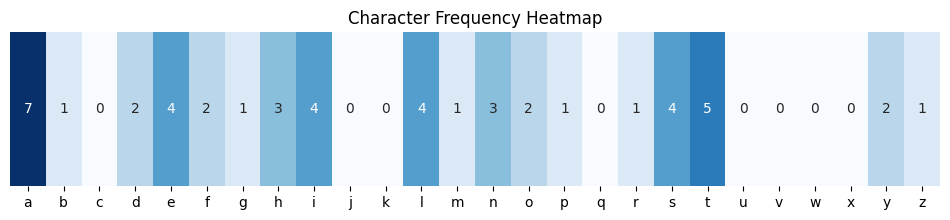

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
import string

# Sample sentence from dataset
sample_text = df['review'][0]  # or any other sentence
chars = [c.lower() for c in sample_text if c.isalpha()]
char_counts = Counter(chars)

# Prepare DataFrame for heatmap
all_chars = list(string.ascii_lowercase)
freqs = [char_counts.get(ch, 0) for ch in all_chars]

# Create a 2D matrix to simulate heatmap (1 row, many columns)
heatmap_data = pd.DataFrame([freqs], columns=all_chars)

plt.figure(figsize=(12, 2))
sns.heatmap(heatmap_data, cmap='Blues', annot=True, fmt="d", cbar=False)
plt.title("Character Frequency Heatmap")
plt.yticks([])  # hide y-axis label (optional)
plt.show()


Dataset: First review sentence.

Feature: Frequency of each alphabet character (case-insensitive).

Observation: Shows which characters dominate in the sentence (e.g. 'a', 'e', 'i' tend to be frequent).

2. Word-Level Representation (Bar Chart)

C:\Users\Admin\AppData\Local\Temp\ipykernel_9276\824757155.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='viridis')


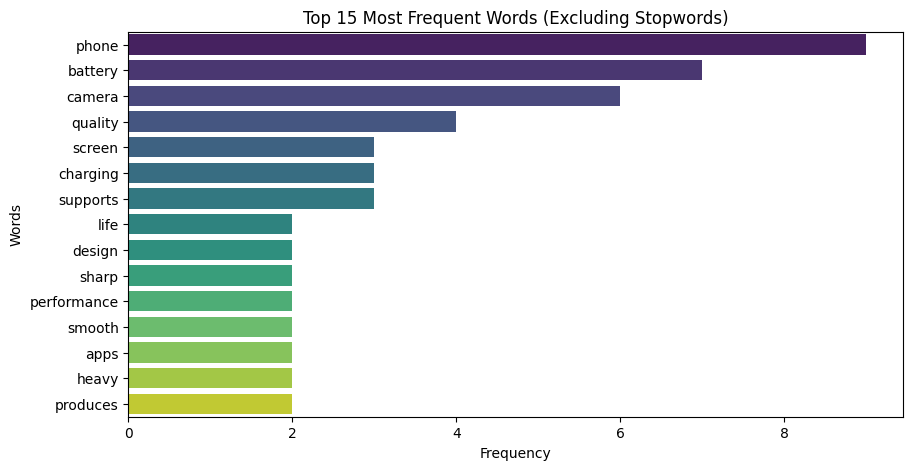

In [5]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Tokenize all reviews, exclude stopwords
all_words = ' '.join(df['review']).lower().split()
filtered_words = [w.strip(string.punctuation) for w in all_words if w not in ENGLISH_STOP_WORDS and w.strip(string.punctuation)]

word_counts = Counter(filtered_words)
top_words = word_counts.most_common(15)

words, counts = zip(*top_words)

plt.figure(figsize=(10,5))
sns.barplot(x=list(counts), y=list(words), palette='viridis')
plt.title("Top 15 Most Frequent Words (Excluding Stopwords)")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()


Dataset: All 50+ reviews combined.

Feature: Word frequency excluding stopwords.

Observation: Common terms include "battery," "camera," "phone," reflecting major review topics.

3. N-Gram Representation (Bar Chart)

C:\Users\Admin\AppData\Local\Temp\ipykernel_9276\3296800119.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(bigrams_list), palette='magma')


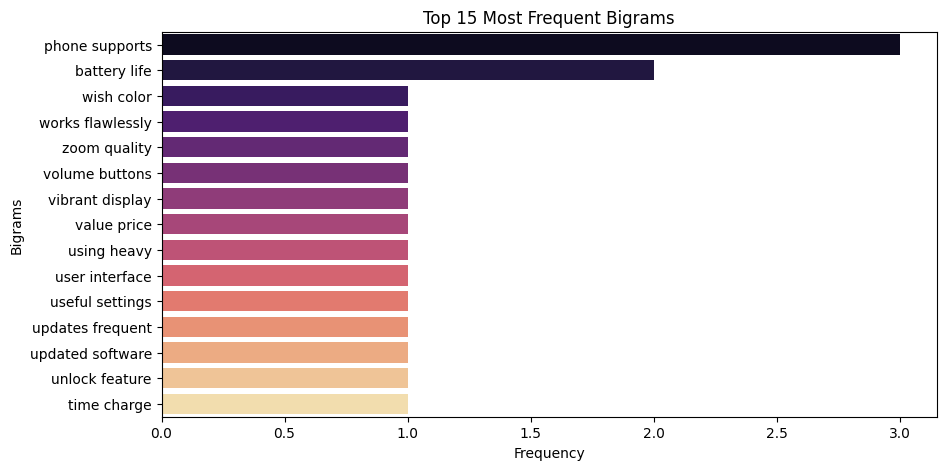

In [6]:
# Use bigrams
vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english')
X = vectorizer.fit_transform(df['review'])
bigrams_counts = np.asarray(X.sum(axis=0)).flatten()
bigrams = vectorizer.get_feature_names_out()

top_bigram_indices = bigrams_counts.argsort()[-15:][::-1]
top_bigrams = [(bigrams[i], bigrams_counts[i]) for i in top_bigram_indices]

bigrams_list, counts = zip(*top_bigrams)

plt.figure(figsize=(10,5))
sns.barplot(x=list(counts), y=list(bigrams_list), palette='magma')
plt.title("Top 15 Most Frequent Bigrams")
plt.xlabel("Frequency")
plt.ylabel("Bigrams")
plt.show()


Dataset: All reviews.

Feature: Top 15 most frequent bigrams (pairs of words).

Observation: Phrases like “battery life”, “camera quality”, “phone heats” appear often showing recurring topics.

4. TF-IDF Representation

A. Heatmap of TF-IDF

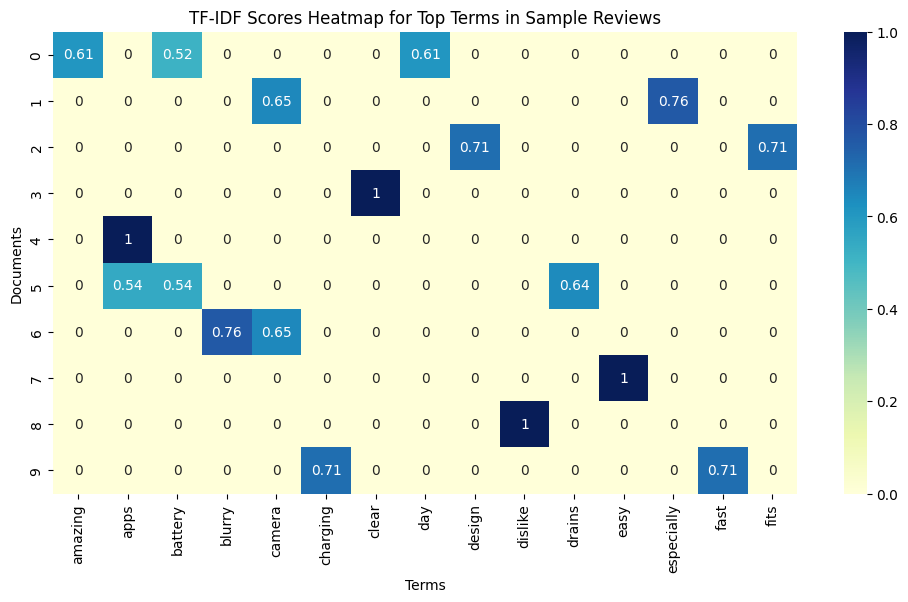

In [7]:
# Take first 10 documents for visualization
docs_sample = df['review'][:10].values

tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=15)
tfidf_matrix = tfidf_vectorizer.fit_transform(docs_sample)

terms = tfidf_vectorizer.get_feature_names_out()
df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=terms)

plt.figure(figsize=(12,6))
sns.heatmap(df_tfidf, annot=True, cmap='YlGnBu')
plt.title("TF-IDF Scores Heatmap for Top Terms in Sample Reviews")
plt.xlabel("Terms")
plt.ylabel("Documents")
plt.show()


B. Runtime Query-Based Search Using TF-IDF

In [ ]:
def query_tfidf_search(query, tfidf_vectorizer, tfidf_matrix, documents):
    query_vec = tfidf_vectorizer.transform([query])
    similarities = cosine_similarity(query_vec, tfidf_matrix).flatten()
    best_idx = similarities.argmax()
    best_score = similarities[best_idx]
    best_doc = documents[best_idx]
    print(f"Most relevant document index: {best_idx}")
    print(f"Similarity score: {best_score:.4f}")
    print(f"Document text: {best_doc}")

query = input("Enter a search query: ").strip()
query_tfidf_search(query, tfidf_vectorizer, tfidf_matrix, docs_sample)


5. Embeddings with spaCy

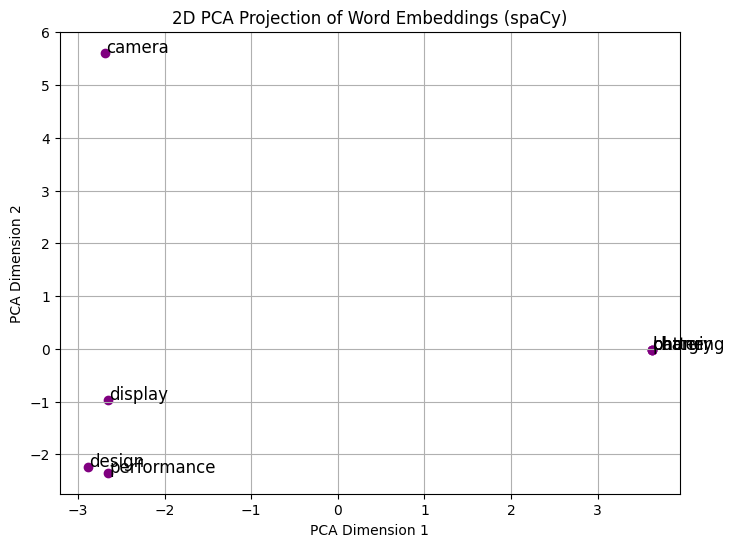

In [11]:
import spacy
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Load the medium English model
nlp = spacy.load("en_core_web_md")

# Words to visualize embeddings
words = ["battery", "camera", "phone", "design", "performance", "charging", "display"]

# Get embeddings
vectors = np.array([nlp(word).vector for word in words])

# Reduce to 2D with PCA
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

plt.figure(figsize=(8,6))
plt.scatter(vectors_2d[:,0], vectors_2d[:,1], color='purple')

for i, word in enumerate(words):
    plt.text(vectors_2d[i,0]+0.01, vectors_2d[i,1]+0.01, word, fontsize=12)

plt.title("2D PCA Projection of Word Embeddings (spaCy)")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.grid(True)
plt.show()


6. Word Cloud

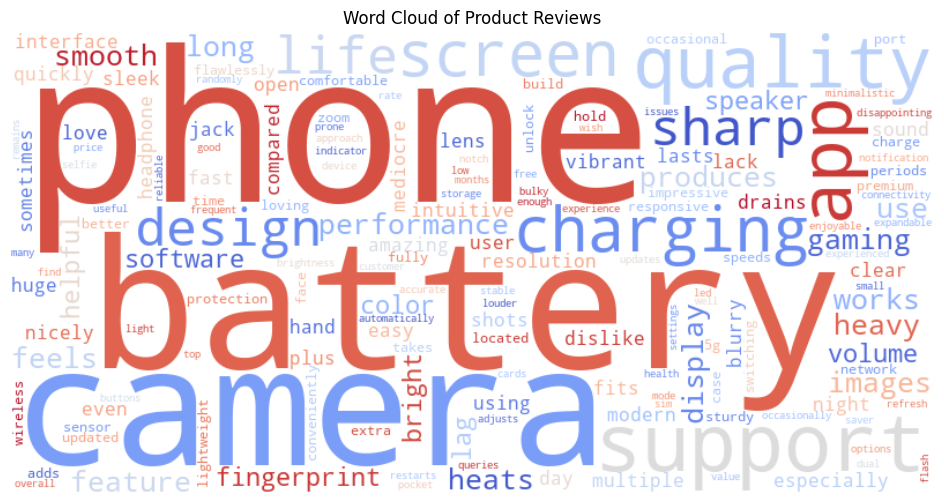

In [10]:
from wordcloud import WordCloud, STOPWORDS

text = " ".join(df['review']).lower()
stopwords = set(STOPWORDS)

wordcloud = WordCloud(width=800, height=400, background_color='white',
                      stopwords=stopwords, colormap='coolwarm').generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Product Reviews")
plt.show()
